# Training a stochastic graph network for MaxCut


<div class="note"><span class="note-t">TL;DR</span>
<p>We train MaxCut with one learnable <code>PISING</code> update per edge, using REINFORCE to weight each sampled bitstring by how much its cut beats a baseline. Samples come from the exact circuit distribution, and the loop carries over unchanged to a hardware sampler.</p>
</div>

In this tutorial, we train a **stochastic graph network** for MaxCut.

One **pbit** sits on each graph node. The circuit places one edge-local `PISING` gate on each edge, tiles those gates over the graph, and repeats the layer for 20 sweeps.

We train the couplings with the REINFORCE gradient estimator (Williams 1992): draw samples from the circuit, score each by its cut, and follow the score-function gradient. This is the estimator that carries over to graphs too large for the exact statevector and to hardware samplers, where the full distribution is never available. Here the graph is small enough that a notebook helper computes the circuit's exact output distribution with `StateVectorSimulator`, which gives us the samples, the expected cut, and the final readout.

This tutorial uses Torx, JAX, Optax, and NumPy (the graph helper uses NetworkX), and assumes basic graph and probability notation. By the end, you'll be able to:

- build the circuit with one `PISING` gate per edge, repeated for 20 sweeps,
- estimate the gradient of the expected cut by REINFORCE from circuit samples, and
- train the edge couplings so the circuit puts more probability on high-cut partitions.

A stochastic graph network is an edge-tiled message-passing circuit.

- Each edge carries one learnable coupling $J_{ij}$.
- Each `PISING` kernel is an edge update: a $4\times4$ column-stochastic Markov matrix, meaning each column of probabilities sums to one. It pushes its two endpoints toward agreement when $J>0$ and disagreement when $J<0$.
- One sweep over all edges is one layer. Repeating sweeps makes the network deeper.
- The readout is the cut value, the number of edges whose endpoints disagree.
- Training raises the expected cut.

Instead of differentiating the expected cut in closed form, we estimate its gradient with REINFORCE: draw bitstrings $x\sim p_\theta$ from the circuit and form

$$
\nabla_\theta\,\mathbb{E}_{p_\theta}[\mathrm{cut}]
\;\approx\;
\frac{1}{M}\sum_{m=1}^{M}\big(\mathrm{cut}(x_m)-b\big)\,\nabla_\theta\log p_\theta(x_m),
$$

where the baseline $b$ (the batch-mean cut) reduces variance without biasing the estimate. An `optax` optimizer then updates the couplings.

## Setup

The setup cells wire up the helper path and apply the shared figure style; the MaxCut utilities come from `examples/helpers/_nb09_maxcut.py`.

In [1]:
from pathlib import Path
import sys

import numpy as np
import jax
import jax.numpy as jnp
import optax

from torx.psc import DiscretePCircuit, PISING



In [2]:
ROOT = Path.cwd()
if not (ROOT / "helpers").exists() and (ROOT.parent / "helpers").exists():
    ROOT = ROOT.parent
HELPER_DIR = ROOT / "helpers"
sys.path.insert(0, str(HELPER_DIR))



In [3]:
from _notebook_paths import figure_dir
from _notebook_style import apply_notebook_style, make_savefig
import _plots_schematics as P_sch
from _nb09_maxcut import (
    random_regular_maxcut,
    brute_force_cuts,
    make_expected_cut,
    cut_distribution,
    edge_pising_matrix,
    plot_training_trajectory,
    plot_cut_distribution,
    plot_partition,
)



In [4]:
FIGURE_DIR = figure_dir(ROOT)
apply_notebook_style()

This small wrapper saves each figure to the gallery directory and displays it inline.

In [5]:
savefig = make_savefig(FIGURE_DIR)

These constants fix the graph instance, the `PISING` gate, and the training budget.

In [6]:
# Graph and gate (locked across the notebook).
NUM_NODES = 8
DEGREE = 3
GRAPH_SEED = 7
BETA = 1.5
DT = 0.5
REPS = 20          # sweeps of the edge layer



In [7]:
# REINFORCE training budget.
J_INIT = -0.2      # small antiferromagnetic start
LEARNING_RATE = 0.1
TRAIN_STEPS = 250
NUM_SAMPLES = 512  # circuit samples per REINFORCE gradient estimate
TRAIN_SEED = 0     # PRNG seed for the sampling

## One PISING per edge

A `PISING` gate gives the pairwise update on one graph edge.

We write each spin as $s_i = 2\sigma_i - 1 \in \{-1, +1\}$. MaxCut maximizes the expected cut. Equivalently, we minimize the loss

$$
\mathcal{L} = \underbrace{-\,\mathbb{E}_{p_\theta}[\mathrm{cut}]}_{\vphantom{\big|}\text{negative cut}} = -\sum_{(i,j)\in\mathcal{E}}\underbrace{\frac{1 - \langle s_i s_j\rangle_{p_\theta}}{2}}_{\vphantom{\big|}\text{per-edge cut}},
$$

where $\langle s_i s_j\rangle_{p_\theta}$ is the spin-spin correlation under the circuit. A cut edge ($s_i \neq s_j$) contributes $1$ and an aligned edge contributes $0$, so lowering $\mathcal{L}$ makes endpoints disagree, which an antiferromagnetic coupling does.

The primitive is the `PISING` operation: we construct `gate = PISING([i, j])` and supply the theta `[J, h_i, h_j, beta, dt]` separately to `get_matrix` or `build_circuit`. It is a $4\times4$ column-stochastic Glauber kernel (a single-spin thermal flip rule) on a pair of pbits. With local fields $h=0$ it biases the joint state toward agreement when $J>0$ and disagreement when $J<0$.

The inverse temperature $\beta$ (how cold the sampler runs, higher is greedier) and timestep $\Delta t$ set how hard each update pushes. One `PISING` gate per edge is a single layer, repeated for several sweeps to deepen the network.

The next cell constructs one edge-local kernel and inspects its stochastic matrix.

In [8]:
# Structure-only gate on sites [0, 1]; its [J, h_i, h_j, beta, dt] parameters
# are a separate theta passed to get_matrix (the real Torx parameter model).
gate_demo = PISING([0, 1])
theta_demo = jnp.array([1.0, 0.0, 0.0, BETA, DT])
M_demo = np.asarray(gate_demo.get_matrix(theta_demo))

print(f"shape: {M_demo.shape}")
print(f"column sums: {np.round(M_demo.sum(axis=0), 8)}")
print(np.round(M_demo, 4))

shape: (4, 4)
column sums: [0.99999994 1.         0.99999994 0.99999994]
[[0.9619 0.3011 0.3011 0.0082]
 [0.015  0.3918 0.0061 0.015 ]
 [0.015  0.0061 0.3918 0.015 ]
 [0.0082 0.3011 0.3011 0.9619]]


In [9]:
np.testing.assert_allclose(
    M_demo.sum(axis=0),
    1.0,
    atol=1e-6,
    err_msg="PISING columns must sum to 1 (column-stochastic)",
)



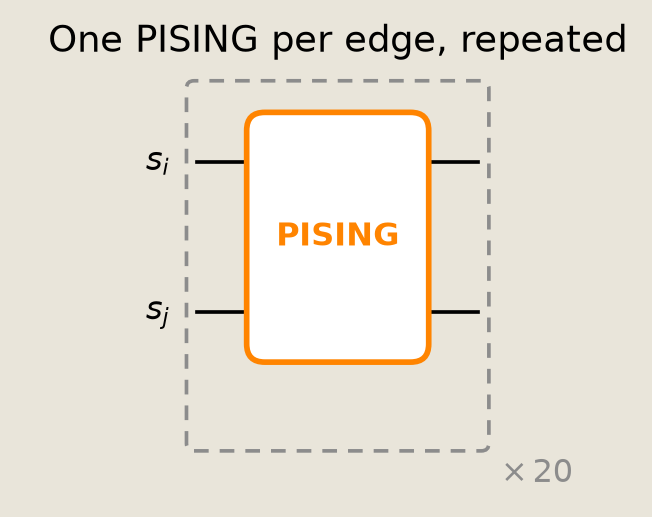

In [10]:
# One edge, drawn as the repeated layer. The full graph circuit tiles this
# PISING across every edge.
edge_circuit = DiscretePCircuit([gate_demo], reps=1)
fig = P_sch.draw_pcircuit(
    edge_circuit,
    reps=REPS,
    wire_labels=[r"$s_i$", r"$s_j$"],
    title="One PISING per edge, repeated",
)
savefig(fig, "09_sgnn_schematic")

The schematic shows one edge-local update repeated across sweeps. The full graph uses the same pattern on every edge.

## The MaxCut instance

A random 3-regular graph on eight nodes gives us a fixed MaxCut instance with a nontrivial optimum.

At this size, the exact statevector has only $2^8 = 256$ entries. We can compute the whole distribution, the brute-force optimum, and the gradient cheaply.

In [11]:
G, edges = random_regular_maxcut(NUM_NODES, DEGREE, seed=GRAPH_SEED)
num_edges = len(edges)

We brute-force all $2^8$ bitstrings for the exact optimum and how many of them reach it.

In [12]:
cut_values, opt_cut, n_optimal = brute_force_cuts(edges, NUM_NODES)

print(f"graph     : {DEGREE}-regular  N={NUM_NODES}  seed={GRAPH_SEED}")
print(f"edges     : {num_edges}")
print(f"MaxCut    : {opt_cut} / {num_edges}")
print(f"# optimal : {n_optimal} bitstrings out of 2^{NUM_NODES}")

graph     : 3-regular  N=8  seed=7
edges     : 12
MaxCut    : 10 / 12
# optimal : 4 bitstrings out of 2^8


## The expected cut from the exact statevector

`make_expected_cut` returns two pure-`jax` functions of the couplings: `density(J)`, the circuit's exact output distribution, and `expected_cut(J)`, the cut averaged over it. Its core is excerpted from `examples/helpers/_nb09_maxcut.py`:

```python
def make_expected_cut(
    edges: _Edges, num_nodes: int, *, beta: float, dt: float, reps: int
):
    ...
    sim = StateVectorSimulator()
    spins = jnp.asarray(spin_table(num_nodes))
    x0 = jnp.ones(2**num_nodes) / float(2**num_nodes)
    edge_sites = [[int(i), int(j)] for i, j in edges]
    # gate structure is static; trainable couplings J enter through theta pytrees
    circuit = DiscretePCircuit([PISING(sites) for sites in edge_sites], reps=reps)
    edge_i = jnp.asarray([i for i, _ in edge_sites])
    edge_j = jnp.asarray([j for _, j in edge_sites])

    def density(J):
        thetas = [
            jnp.stack([J[e], 0.0, 0.0, jnp.asarray(beta), jnp.asarray(dt)])
            for e in range(len(edge_sites))
        ]
        compiled = sim.build_circuit(circuit, thetas)
        return sim.density(compiled, x0)

    def expected_cut(J):
        rho = density(J)
        edge_products = spins[:, edge_i] * spins[:, edge_j]
        correlations = rho @ edge_products
        return jnp.sum((1.0 - correlations) / 2.0)

    return expected_cut, density
```

It propagates the uniform start through one `PISING`-per-edge layer repeated `REPS` times and reads the spin-spin correlations off the result.

We use `density` two ways below: to draw the samples for the REINFORCE estimate (its log gives the score $\nabla_\theta\log p_\theta$), and to evaluate the exact expected cut so we can track training against the optimum. We never differentiate `expected_cut` for the updates; that closed-form gradient is what REINFORCE replaces.

Before training, we evaluate the expected cut at the initial couplings and at the uniform baseline, the mean cut of a random assignment. That baseline is the floor any learner should clear.

In [13]:
# Build the exact readout once, then reuse it for all couplings.
expected_cut, density = make_expected_cut(edges, NUM_NODES, beta=BETA, dt=DT, reps=REPS)

J_init = jnp.full((num_edges,), J_INIT)
uniform_mean = float(cut_values.mean())

print(f"expected cut at initialization: {float(expected_cut(J_init)):.2f}")
print(f"uniform baseline (mean cut):    {uniform_mean:.2f}")
print(f"brute-force optimum:            {opt_cut} / {num_edges}")

expected cut at initialization: 6.51
uniform baseline (mean cut):    6.00
brute-force optimum:            10 / 12


## Training by REINFORCE

We maximize $\mathbb{E}_{p_\theta}[\mathrm{cut}]$ with the REINFORCE (score-function) gradient estimator and `optax.adam`.

Each step draws `NUM_SAMPLES` bitstrings from the circuit's output distribution $p_\theta$, scores each by its cut, and estimates

$$
\nabla_\theta\,\mathbb{E}_{p_\theta}[\mathrm{cut}]
\;\approx\;
\frac{1}{M}\sum_{m=1}^{M}\big(\mathrm{cut}(x_m)-b\big)\,\nabla_\theta\log p_\theta(x_m),
\qquad x_m\sim p_\theta .
$$

The baseline $b$ is the batch-mean cut. Subtracting it leaves the estimate unbiased while cutting its variance. In code we minimize the stop-gradient surrogate $-\frac{1}{M}\sum_m \mathrm{sg}(\mathrm{cut}(x_m)-b)\,\log p_\theta(x_m)$, whose gradient is exactly the estimate above. Unlike the closed-form gradient of the expectation, this uses only samples and their log-probabilities, so it carries over to large graphs and hardware samplers where the full distribution is out of reach.

In [14]:
def train_couplings(density_fn, expected_cut_fn, cut_values, num_edges, *,
                    steps, num_samples, lr, key):
    """Train one coupling vector with the REINFORCE score-function estimator.

    Each step samples ``num_samples`` bitstrings from the circuit distribution
    ``p_J``, weights each sample's score ``grad_J log p_J(x)`` by its centered
    cut ``(cut - batch-mean baseline)``, and ascends with Adam. The exact
    ``expected_cut_fn`` is evaluated only to record the trajectory.
    """
    cut_values = jnp.asarray(cut_values)

    def surrogate(J, key):
        logp = jnp.log(density_fn(J) + 1e-12)            # log p_J over all states
        idx = jax.random.categorical(
            key, jax.lax.stop_gradient(logp), shape=(num_samples,)
        )                                                # x_m ~ p_J
        cuts = cut_values[idx]                           # cut of each sampled bitstring
        baseline = jnp.mean(cuts)                        # variance-reduction baseline
        # grad of this surrogate == the REINFORCE estimate of -grad E[cut]
        return -jnp.mean((cuts - baseline) * logp[idx])

    reinforce_grad = jax.jit(jax.grad(surrogate))
    expected_cut_jit = jax.jit(expected_cut_fn)
    optimizer = optax.adam(lr)
    J = jnp.full((num_edges,), J_INIT)
    opt_state = optimizer.init(J)

    expected_hist = []
    for _ in range(steps):
        key, subkey = jax.random.split(key)
        grads = reinforce_grad(J, subkey)
        updates, opt_state = optimizer.update(grads, opt_state)
        J = optax.apply_updates(J, updates)
        expected_hist.append(float(expected_cut_jit(J)))  # exact E[cut], for the trajectory only
    return J, expected_hist




In [15]:
J_star, expected_hist = train_couplings(
    density, expected_cut, cut_values, num_edges,
    steps=TRAIN_STEPS, num_samples=NUM_SAMPLES, lr=LEARNING_RATE,
    key=jax.random.PRNGKey(TRAIN_SEED),
)

expected cut 6.75 -> 9.99   (optimum 10)


trained couplings: mean -2.26, std 2.52


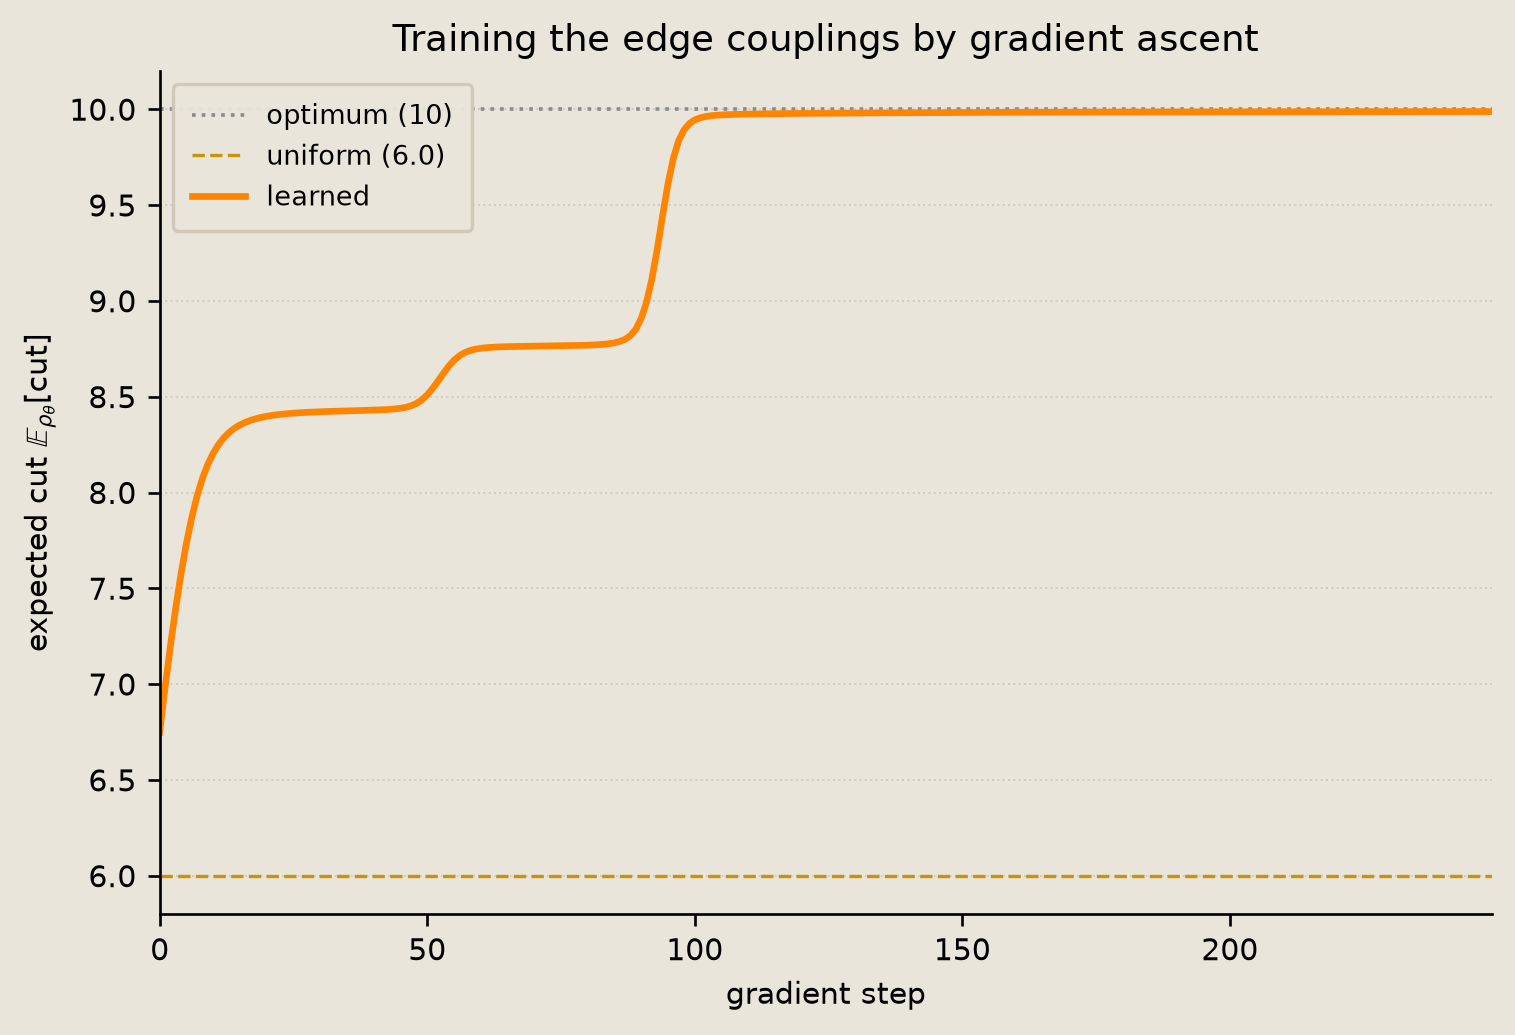

In [16]:
print(f"expected cut {expected_hist[0]:.2f} -> {expected_hist[-1]:.2f}   (optimum {opt_cut})")
print(f"trained couplings: mean {float(J_star.mean()):.2f}, std {float(J_star.std()):.2f}")

assert expected_hist[-1] > expected_hist[0], "REINFORCE training must raise the expected cut"

fig = plot_training_trajectory(
    expected_hist, opt=opt_cut, uniform_mean=uniform_mean,
)
savefig(fig, "09_sgnn_training")

The expected cut climbs in stages, pausing on two intermediate plateaus before settling at the optimum. It starts above the uniform baseline and only widens the gap. The first recorded value already includes the first Adam step, which is why it sits slightly above the expected cut at initialization.

## What the circuit learned

Training reshapes the whole output distribution.

We compare the cut distribution of the trained circuit against the uniform baseline to see where each one puts its probability mass.

In [17]:
# Convert exact output distributions into distributions over cut values.
rho_learned = np.asarray(density(J_star))
cut_support = np.arange(num_edges + 1)

uniform_dist = cut_distribution(
    np.full(2**NUM_NODES, 1.0 / 2**NUM_NODES),
    cut_values,
    num_edges,
)
learned_dist = cut_distribution(rho_learned, cut_values, num_edges)

learned mass on the optimum   : 0.996
learned mass on cut >= 9      : 0.997


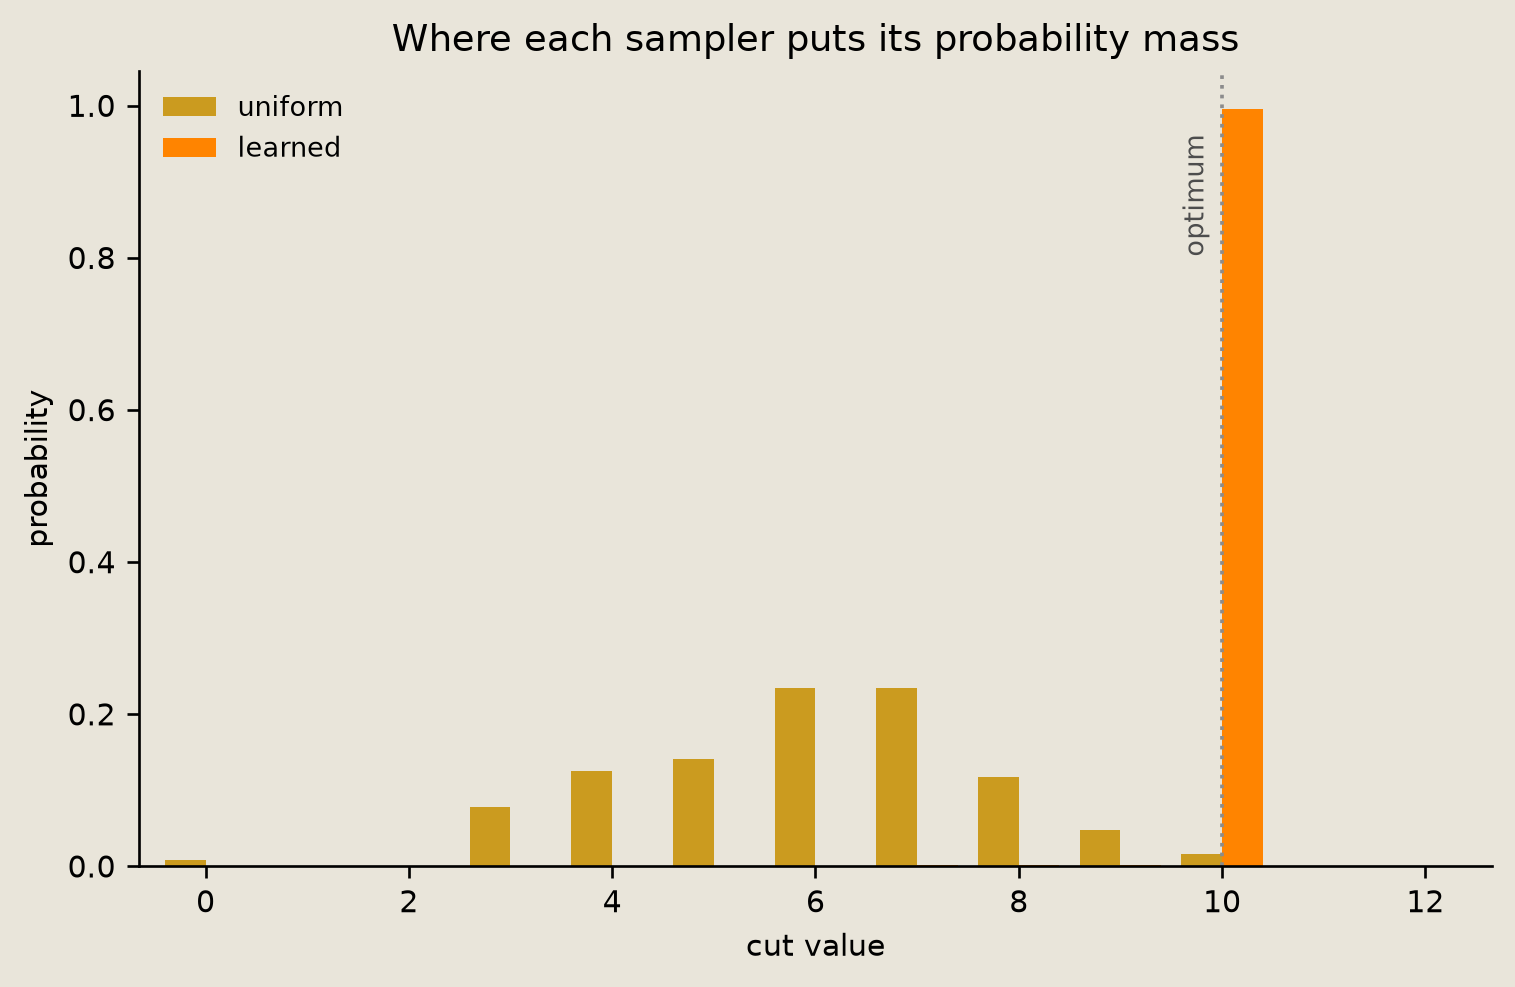

In [18]:
print(f"learned mass on the optimum   : {learned_dist[opt_cut]:.3f}")
print(
    f"learned mass on cut >= {opt_cut - 1}      : {learned_dist[opt_cut - 1:].sum():.3f}"
)

fig = plot_cut_distribution(
    cut_support,
    uniform_dist,
    learned_dist,
    opt=opt_cut,
)
savefig(fig, "09_sgnn_cut_distribution")

The learned distribution puts most of its probability on the highest cut values. The uniform baseline stays spread out well below the optimum.

The most probable trained bitstring is the partition the circuit favors. We draw it with its cut edges highlighted.

In [19]:
# Decode the most likely state index into one bit per graph node.
best_index = int(np.argmax(rho_learned))
partition = np.array(
    [(best_index >> (NUM_NODES - 1 - q)) & 1 for q in range(NUM_NODES)]
)
learned_cut = int(sum(partition[i] != partition[j] for i, j in edges))



most-probable bitstring cut: 10 / 12


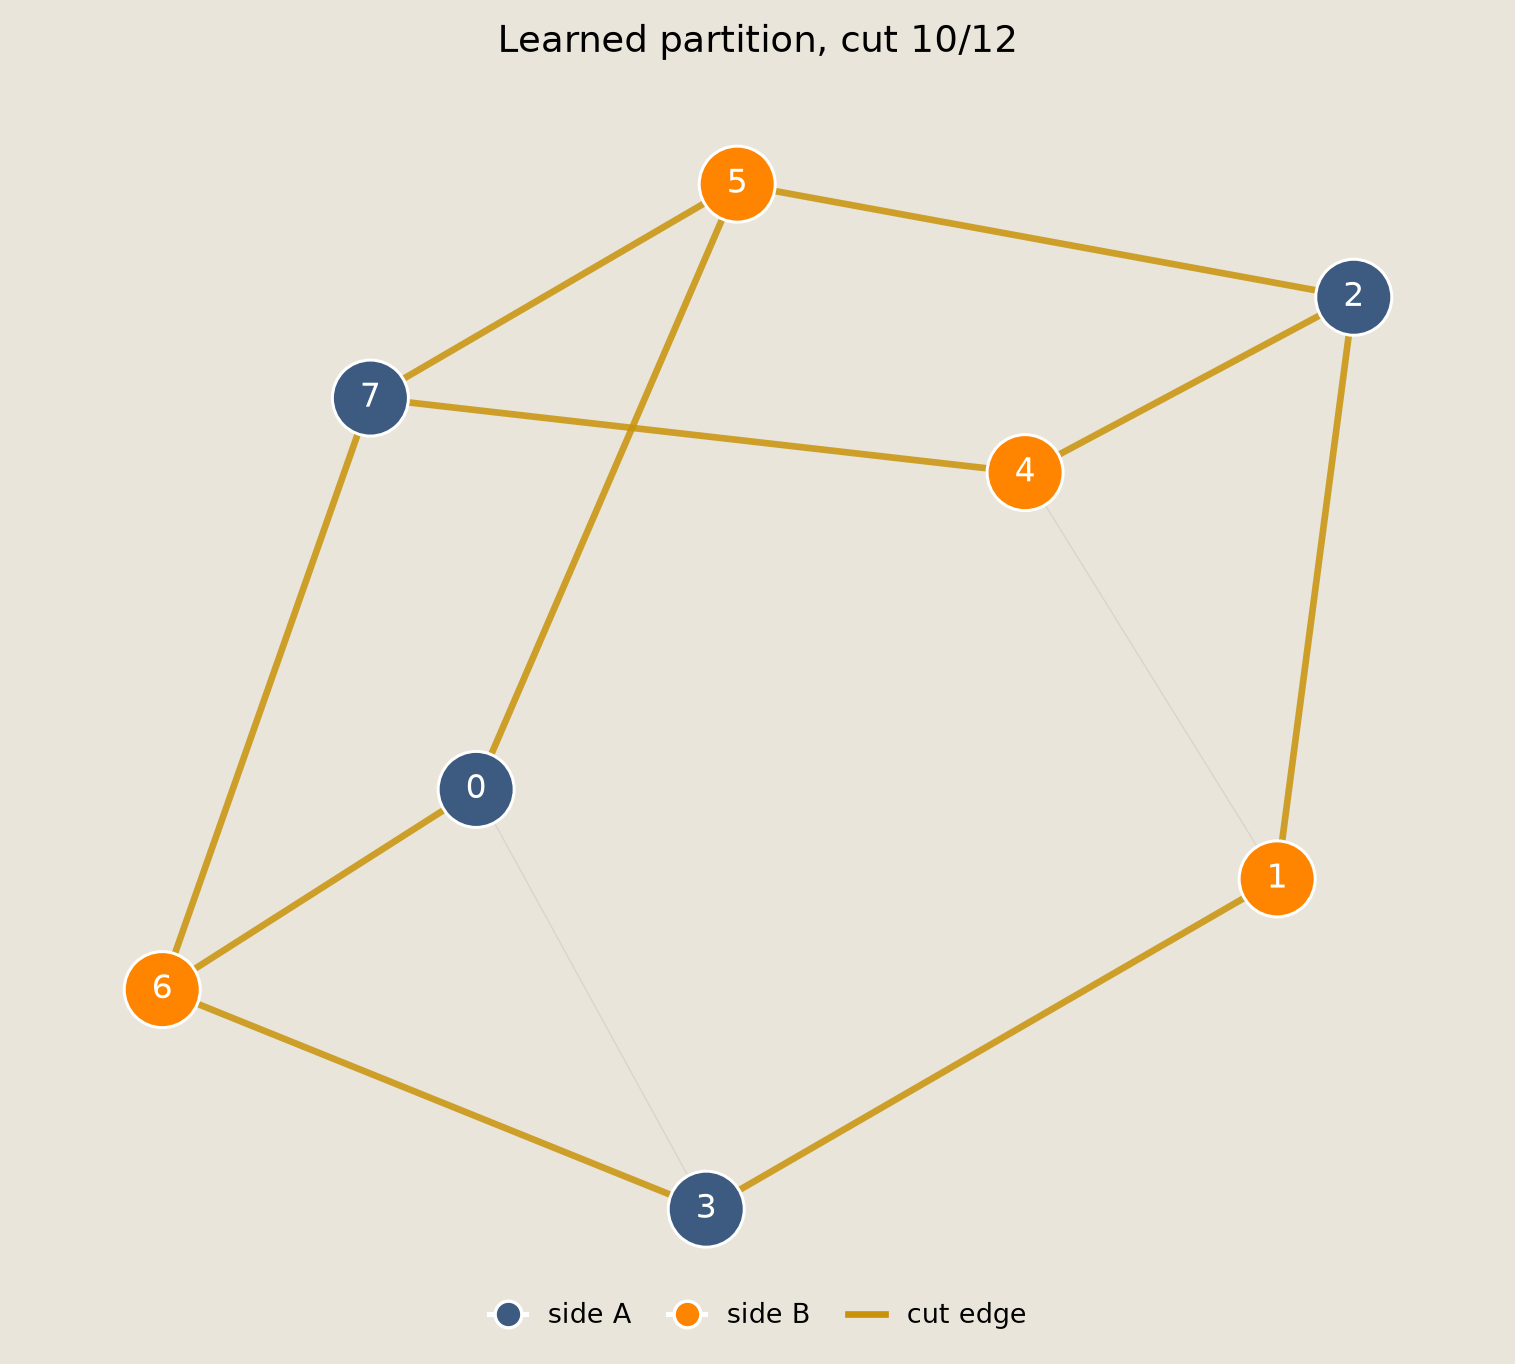

In [20]:
print(f"most-probable bitstring cut: {learned_cut} / {num_edges}")

fig = plot_partition(
    G,
    partition,
    learned_cut=learned_cut,
    num_edges=num_edges,
    layout_seed=GRAPH_SEED,
)
savefig(fig, "09_sgnn_graph")

The partition plot shows the most probable learned bitstring and the edges crossing its cut.

## Verification

The final checks collect the assumptions used above.

We check that the trained kernels are stochastic, REINFORCE training improved the expected cut past the uniform baseline, the trained distribution concentrates on near-optimal cuts, the most probable bitstring is optimal, and the result is not specific to one graph instance.

In [21]:
# 1) Each trained PISING edge is column-stochastic.
trained_mats = np.stack([edge_pising_matrix(float(j), beta=BETA, dt=DT) for j in J_star])
np.testing.assert_allclose(trained_mats.sum(axis=-2), 1.0, atol=1e-6)

# 2) REINFORCE training raised the expected cut past the uniform baseline.
assert expected_hist[-1] > expected_hist[0]
assert expected_hist[-1] > uniform_mean

# 3) The trained distribution concentrates on near-optimal cuts.
assert learned_dist[opt_cut - 1:].sum() > 0.5

# 4) The most-probable trained bitstring is an optimal cut.
assert learned_cut == opt_cut

In [22]:
# 5) Robustness: on three other random graphs, REINFORCE reaches near the optimum.
for seed in (11, 23, 41):
    G_s, edges_s = random_regular_maxcut(NUM_NODES, DEGREE, seed=seed)
    ec_s, density_s = make_expected_cut(edges_s, NUM_NODES, beta=BETA, dt=DT, reps=REPS)
    cut_values_s, opt_s, _ = brute_force_cuts(edges_s, NUM_NODES)
    J_s, _ = train_couplings(
        density_s, ec_s, cut_values_s, len(edges_s),
        steps=TRAIN_STEPS, num_samples=NUM_SAMPLES, lr=LEARNING_RATE,
        key=jax.random.PRNGKey(seed),
    )
    assert float(ec_s(J_s)) > 0.8 * opt_s

With the assertions passing, we print the headline numbers.

In [23]:
print("all checks passed")
print(f"  expected cut   {expected_hist[0]:.2f} -> {expected_hist[-1]:.2f}  (optimum {opt_cut})")
print(f"  learned mass on optimum   {learned_dist[opt_cut]:.3f}")
print(f"  uniform / learned : {uniform_mean:.2f} / {expected_hist[-1]:.2f}")

all checks passed
  expected cut   6.75 -> 9.99  (optimum 10)
  learned mass on optimum   0.996
  uniform / learned : 6.00 / 9.99


## Conclusion

We built a stochastic graph network for MaxCut with one `PISING` gate per edge, then trained its couplings with the REINFORCE score-function estimator.

- Each edge becomes one column-stochastic Glauber update that biases the bond toward agreement when $J>0$ and disagreement when $J<0$. Tiling it over all edges and repeating the sweep gives the network.
- Training maximizes $\mathbb{E}_{p_\theta}[\mathrm{cut}]$ by REINFORCE: sample bitstrings from the circuit, weight each sample's score $\nabla_\theta\log p_\theta(x)$ by its cut minus a baseline, and step with `optax.adam`. The estimate uses only samples and their log-probabilities; the baseline keeps its variance in check.
- Samples come from the circuit's exact output distribution here (the graph is small); the estimator itself never needs the full distribution, so it carries over to hardware samplers.
- REINFORCE raises the expected cut in stages, through two intermediate plateaus, to the optimum, starting above the uniform baseline and only widening the gap. It concentrates almost all of the probability mass on the optimal partitions; on three extra graph instances it reaches at least 80% of the optimum.

See also:

- [`06_ising_sampling_contrastive_divergence.ipynb`](06_ising_sampling_contrastive_divergence.ipynb), which covers the `PISING` Glauber kernel and learning its couplings.
- [`04_execution_interface_readouts.ipynb`](04_execution_interface_readouts.ipynb), which covers how the simulators estimate expectations.
- [`08_stochastic_convolutional_networks.ipynb`](08_stochastic_convolutional_networks.ipynb), the sibling stochastic-network construction.

## References

1. Williams, R.J. 1992. [*Simple statistical gradient-following algorithms for connectionist reinforcement learning*](https://link.springer.com/article/10.1007/BF00992696). Mach. Learn. 8, 229-256.

